# Exercise 1: Fully Connected and Convolutional Neural Networks

**Group Members (please state here)**:
1.   Yi-Hui Fan
2.   Avik Das
3.   

**Please submit as groups of no more than three students.**

---

**Note**: For this assignment, it is **highly recommended that you use a GPU** to speed up the training process, especially for the convolutional neural network (CNN) model. Training on a CPU can be significantly slower, particularly for models with many parameters. If you don't have access to a GPU, you can use free resources like Kaggle Notebooks or Google Colab, which  offer free GPU support.





## 1. Load and Explore the MNIST Dataset



### 1.1 Import Libraries

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import layers

### 1.2 Load Dataset

Load the MNIST dataset, a collection of 28x28 grayscale images representing handwritten digits from 0 to 9, using [TensorFlow's `datasets` module](https://www.tensorflow.org/datasets). Visualize the dataset by displaying a grid of 16 randomly selected images along with their labels.

In [2]:
# load MNIST dataset from TensorFlow
(ds_train, ds_test), ds_info = tfds.load(
    'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.P23P62_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.P23P62_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


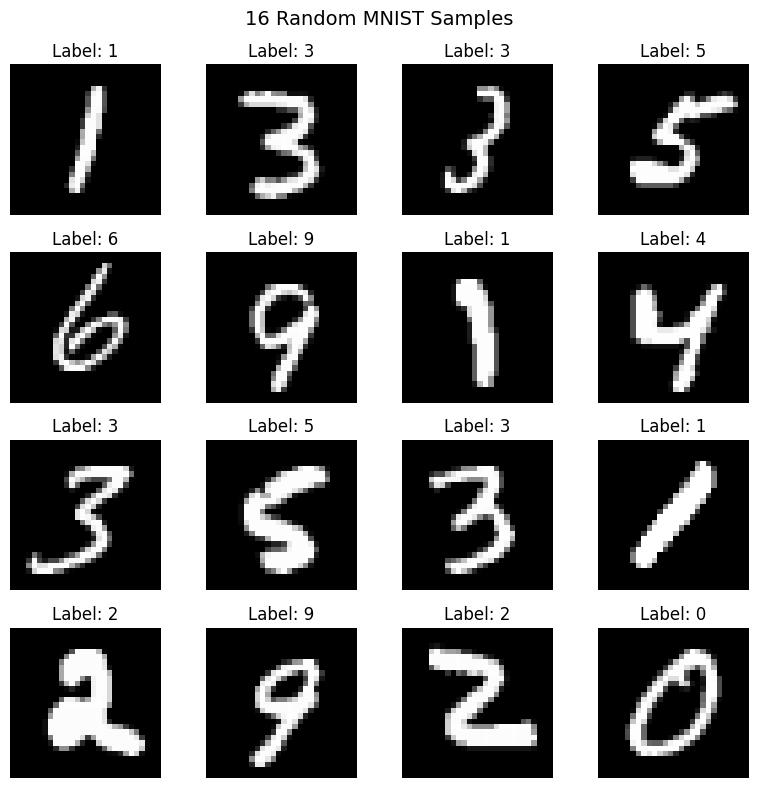

In [3]:
# visualize 16 randomly selected images along with their labels
import matplotlib.pyplot as plt
import numpy as np

samples = list(ds_train.shuffle(1000).take(16))

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, (image, label) in enumerate(samples):
    ax = axes[i // 4][i % 4]
    ax.imshow(image.numpy().squeeze(), cmap='gray')
    ax.set_title(f'Label: {label.numpy()}')
    ax.axis('off')

plt.suptitle('16 Random MNIST Samples', fontsize=14)
plt.tight_layout()
plt.show()

### 1.3 Data Preprocessing

Preprocess the data by normalizing the pixel values to the range [0, 1].

In [4]:
# normalize the pixel values to the range [0, 1]
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

ds_train = ds_train.map(normalize)
ds_test = ds_test.map(normalize)

## 2. Define and Train a Fully Connected Neural Network (FCN)

Using [TensorFlow's keras API](https://keras.io/api/), define a fully connected neural network (FCN) with the following architecture:

* **Input Layer**: A flattened version of the 28x28 input images (i.e., shape (784,)).
* **Hidden Layers**: Two dense layers, each with 128 neurons and ReLU activation.
* **Output Layer**: A dense layer with 10 neurons (one per digit) and softmax activation for classification.

Train the model using the Adam optimizer with a learning rate of 0.001, cross-entropy loss, and track accuracy. Train for 10 epochs with a batch size of 32. Evaluate the test accuracy and analyze the training process using the learning curves (loss and accuracy).




In [6]:
# define model layer-by-layer using TensorFlow/keras
model_fcn = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_fcn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_fcn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# train the model
history_fcn = model_fcn.fit(
    ds_train.batch(32),
    epochs=10,
    validation_data=ds_test.batch(32)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9330 - loss: 0.2281 - val_accuracy: 0.9581 - val_loss: 0.1308
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9707 - loss: 0.0964 - val_accuracy: 0.9693 - val_loss: 0.0978
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9794 - loss: 0.0657 - val_accuracy: 0.9732 - val_loss: 0.0908
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9857 - loss: 0.0468 - val_accuracy: 0.9731 - val_loss: 0.0907
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9884 - loss: 0.0364 - val_accuracy: 0.9748 - val_loss: 0.0943
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9900 - loss: 0.0304 - val_accuracy: 0.9677 - val_loss: 0.1251
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9914 - loss: 0.0250 - val_accuracy: 0.9766 - val_loss: 0.0947
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9928 - loss: 0.0217

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9768 - loss: 0.1082
Test Accuracy: 0.9768
Test Loss: 0.1082


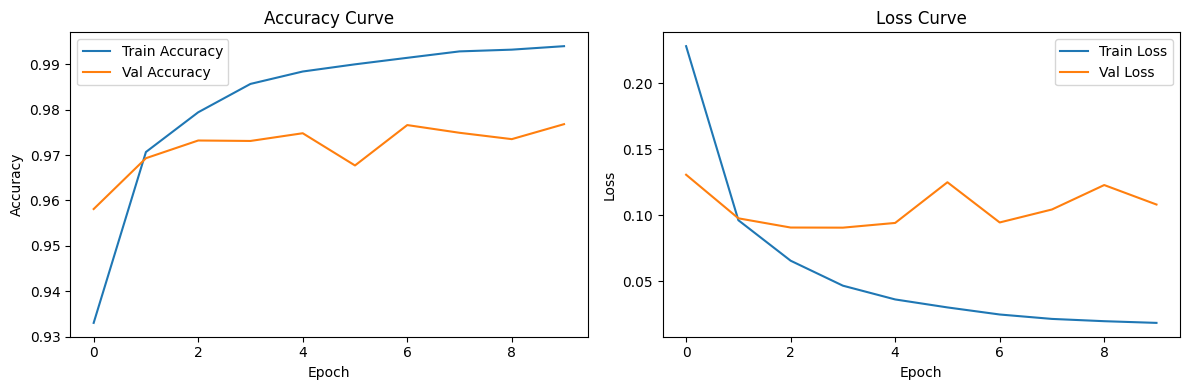

In [8]:
# evaluate the model
test_loss, test_acc = model_fcn.evaluate(ds_test.batch(32))
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

# plot learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# accuracy curve
axes[0].plot(history_fcn.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_fcn.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# loss curve
axes[1].plot(history_fcn.history['loss'], label='Train Loss')
axes[1].plot(history_fcn.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Define and Train a Convolutional Neural Network (CNN)

Create a convolutional neural network (CNN) for MNIST classification using TensorFlow's keras API with the following architecture:

* **Input Layer**: Accepts 28x28 grayscale images with shape (28, 28, 1).
* **Conv2D Layer 1**: 32 filters, kernel size (3, 3), ReLU activation.
* **MaxPooling2D Layer**: Pool size (2, 2) for spatial down-sampling.
* **Conv2D Layer 2**: 64 filters, kernel size (3, 3), ReLU activation.
* **MaxPooling2D Layer**: Pool size (2, 2).
* **Flatten Layer**: Converts the 2D feature map into a 1D vector.
* **Dense Layer**: 128 neurons with ReLU activation.
* **Output Layer**: A dense layer with 10 neurons (softmax activation).

Train this CNN using the same setup as in Task 2. Adjust the learning rate, epoch count, and batch size if necessary. After training, compare its test accuracy and training process to the FCN from Task 2.

In [9]:
# define model layer-by-layer using TensorFlow/keras
model_cnn = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# train the model
history_cnn = model_cnn.fit(
    ds_train.batch(32),
    epochs=10,
    validation_data=ds_test.batch(32)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9610 - loss: 0.1256 - val_accuracy: 0.9830 - val_loss: 0.0517
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9877 - loss: 0.0410 - val_accuracy: 0.9884 - val_loss: 0.0358
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9921 - loss: 0.0263 - val_accuracy: 0.9882 - val_loss: 0.0379
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9938 - loss: 0.0191 - val_accuracy: 0.9902 - val_loss: 0.0303
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9956 - loss: 0.0137 - val_accuracy: 0.9899 - val_loss: 0.0378
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9962 - loss: 0.0118 - val_accuracy: 0.9897 - val_loss: 0.0386
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9968 - loss: 0.0086 - val_accuracy: 0.9890 - val_loss: 0.0481
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9973 - loss: 0.0082 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9891 - loss: 0.0493
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9768 - loss: 0.1082
CNN  - Test Accuracy: 0.9891 | Test Loss: 0.0493
FCN  - Test Accuracy: 0.9768 | Test Loss: 0.1082


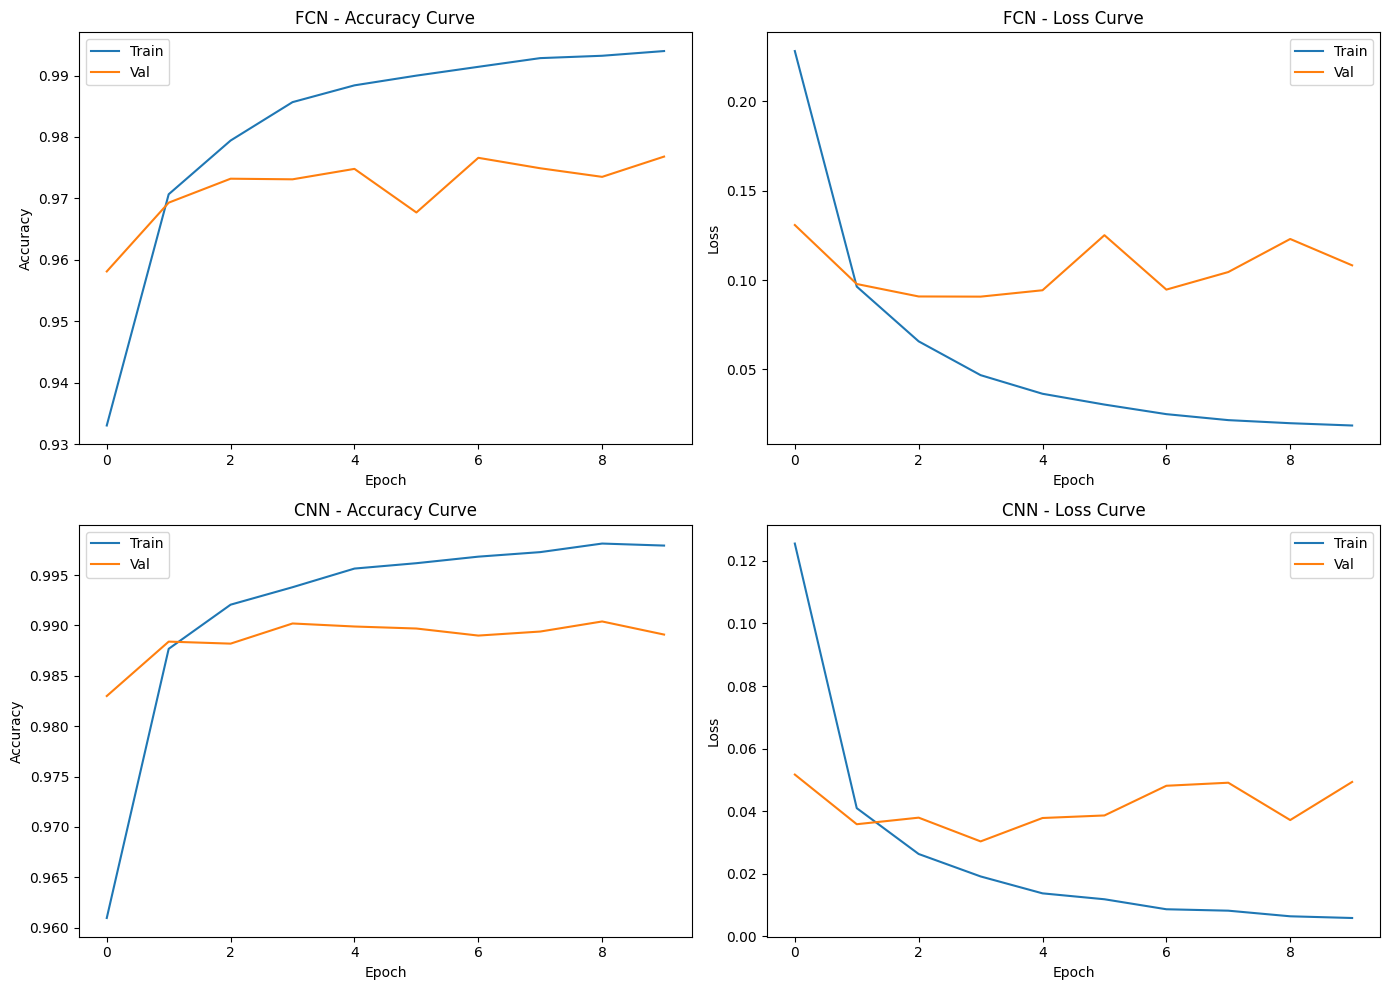

In [11]:
# evaluate the model and compare it to the FCN from task 2
cnn_loss, cnn_acc = model_cnn.evaluate(ds_test.batch(32))
fcn_loss, fcn_acc = model_fcn.evaluate(ds_test.batch(32))

print(f'CNN  - Test Accuracy: {cnn_acc:.4f} | Test Loss: {cnn_loss:.4f}')
print(f'FCN  - Test Accuracy: {fcn_acc:.4f} | Test Loss: {fcn_loss:.4f}')

# plot learning curves comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# FCN accuracy
axes[0][0].plot(history_fcn.history['accuracy'], label='Train')
axes[0][0].plot(history_fcn.history['val_accuracy'], label='Val')
axes[0][0].set_title('FCN - Accuracy Curve')
axes[0][0].set_xlabel('Epoch')
axes[0][0].set_ylabel('Accuracy')
axes[0][0].legend()

# FCN loss
axes[0][1].plot(history_fcn.history['loss'], label='Train')
axes[0][1].plot(history_fcn.history['val_loss'], label='Val')
axes[0][1].set_title('FCN - Loss Curve')
axes[0][1].set_xlabel('Epoch')
axes[0][1].set_ylabel('Loss')
axes[0][1].legend()

# CNN accuracy
axes[1][0].plot(history_cnn.history['accuracy'], label='Train')
axes[1][0].plot(history_cnn.history['val_accuracy'], label='Val')
axes[1][0].set_title('CNN - Accuracy Curve')
axes[1][0].set_xlabel('Epoch')
axes[1][0].set_ylabel('Accuracy')
axes[1][0].legend()

# CNN loss
axes[1][1].plot(history_cnn.history['loss'], label='Train')
axes[1][1].plot(history_cnn.history['val_loss'], label='Val')
axes[1][1].set_title('CNN - Loss Curve')
axes[1][1].set_xlabel('Epoch')
axes[1][1].set_ylabel('Loss')
axes[1][1].legend()

plt.tight_layout()
plt.show()